<a href="https://colab.research.google.com/github/rottemdav/projectA/blob/main/video_processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [64]:
#imports 
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import glob
import os

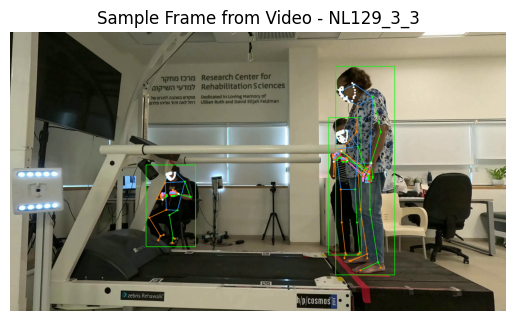

In [3]:
# print a sample frame from the video
# /home/projects/sipl-prj10496/project_files/data/output/20260526_183051/NL129_3_3_pose_20260526_183051_0_to_end.mp4
video_path = "/home/projects/sipl-prj10496/project_files/data/output/20260526_183051/NL129_3_3_pose_20260526_183051_0_to_end.mp4"
cap = cv2.VideoCapture(video_path)
ret, frame = cap.read()
if ret:
    plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title('Sample Frame from Video - NL129_3_3')
    plt.show()
else:
    print("Failed to read video.")
cap.release()

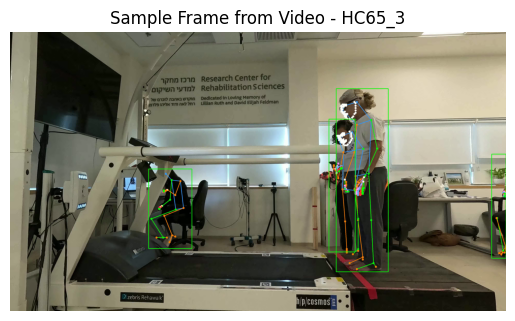

In [4]:
# print a sample frame from the video
# /home/projects/sipl-prj10496/project_files/data/output/20260526_180118/HC65_3_keypoints_20260526_180118_0_to_end.json
video_path = "/home/projects/sipl-prj10496/project_files/data/output/20260526_180118/HC65_3_pose_20260526_180118_0_to_end.mp4"
cap = cv2.VideoCapture(video_path)
ret, frame = cap.read()
if ret:
    plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title('Sample Frame from Video - HC65_3')
    plt.show()
else:
    print("Failed to read video.")
cap.release()

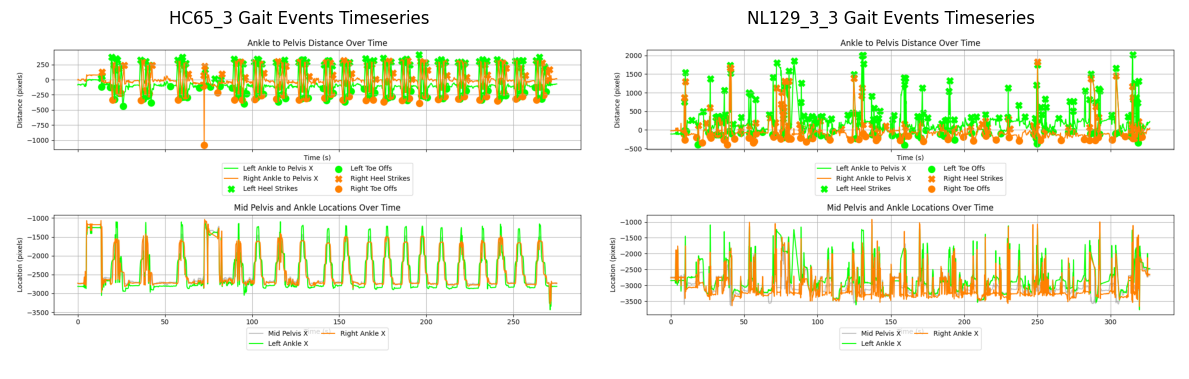

In [ ]:
#show these images side by side: 
# image 1: /home/projects/sipl-prj10496/project_files/outputs/hrnet_wholebody_output/20260526_220109/HC65_3_gait_events_timeseries_1.png
# image 2: /home/projects/sipl-prj10496/project_files/outputs/hrnet_wholebody_output/20260526_221113/NL129_3_3_gait_events_timeseries.png

image1_path = "/home/projects/sipl-prj10496/project_files/outputs/hrnet_wholebody_output/20260526_220109/HC65_3_gait_events_timeseries_1.png"
image2_path = "/home/projects/sipl-prj10496/project_files/outputs/hrnet_wholebody_output/20260526_221113/NL129_3_3_gait_events_timeseries.png"
image1 = cv2.imread(image1_path)
image2 = cv2.imread(image2_path)
image1_rgb = cv2.cvtColor(image1, cv2.COLOR_BGR2RGB)
image2_rgb = cv2.cvtColor(image2, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(image1_rgb)
plt.axis('off')
plt.title('HC65_3 Gait Events Timeseries')
plt.subplot(1, 2, 2)
plt.imshow(image2_rgb)
plt.axis('off')
plt.title('NL129_3_3 Gait Events Timeseries')
plt.tight_layout()
plt.show()  

In [21]:
# /home/projects/sipl-prj10496/project_files/outputs/hrnet_wholebody_output/20260526_221113/NL129_3_3_steps.parquet
# /home/projects/sipl-prj10496/project_files/outputs/hrnet_wholebody_output/20260526_220109/HC65_3_steps.parquet

NL129_steps = pd.read_parquet("/home/projects/sipl-prj10496/project_files/outputs/hrnet_wholebody_output/20260526_221113/NL129_3_3_steps.parquet")
NL129_summary = pd.read_parquet("/home/projects/sipl-prj10496/project_files/outputs/hrnet_wholebody_output/20260526_221113/NL129_3_3_summary.parquet")
NL129_spatial = pd.read_parquet("/home/projects/sipl-prj10496/project_files/outputs/hrnet_wholebody_output/20260529_173236/NL129_3_3_spatial.parquet")
HC65_steps = pd.read_parquet("/home/projects/sipl-prj10496/project_files/outputs/hrnet_wholebody_output/20260526_220109/HC65_3_steps.parquet")
HC65_summary = pd.read_parquet("/home/projects/sipl-prj10496/project_files/outputs/hrnet_wholebody_output/20260526_220109/HC65_3_summary.parquet")
HC65_spatial = pd.read_parquet("/home/projects/sipl-prj10496/project_files/outputs/hrnet_wholebody_output/20260529_173308/HC65_3_spatial.parquet")

#print("Steps DataFrame:")
#print(NL129_steps.head())

#print("\nSummary DataFrame:")
#print(NL129_summary)

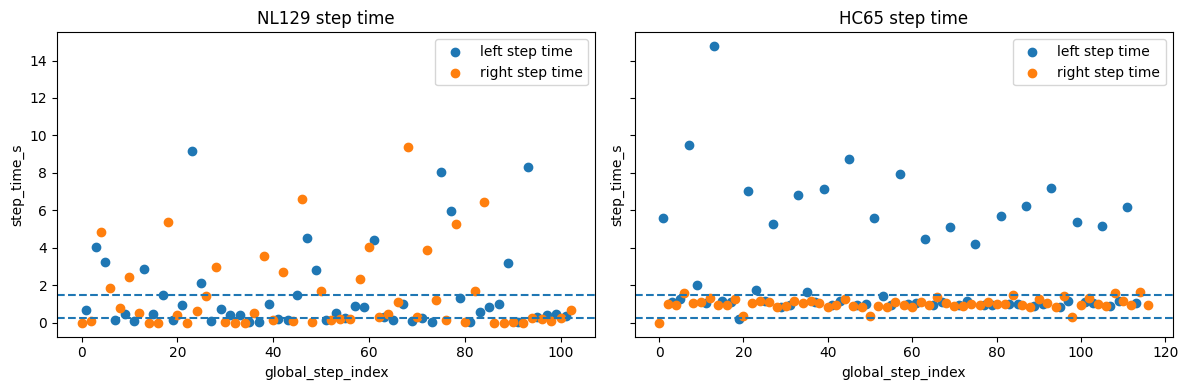

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

HC65_valid = HC65_steps[HC65_steps["valid"]].copy()

HC65_plot = HC65_steps.copy()

for side, df_side in HC65_plot.groupby("side"):
    df_side = df_side.sort_values("global_step_index")

    axes[1].scatter(
        df_side["global_step_index"],
        df_side["step_time_s"],
        label=f"{side} step time",
    )

axes[1].axhline(1.5, linestyle="--")
axes[1].axhline(0.25, linestyle="--")
axes[1].set_title("HC65 step time")
axes[1].set_xlabel("global_step_index")
axes[1].set_ylabel("step_time_s")
axes[1].legend()

NL129_valid = NL129_steps[NL129_steps["valid"]].copy()
NL129_plot = NL129_steps.copy()

for side, df_side in NL129_plot.groupby("side"):
    df_side = df_side.sort_values("global_step_index")

    axes[0].scatter(
        df_side["global_step_index"],
        df_side["step_time_s"],
        label=f"{side} step time",
    )

axes[0].axhline(1.5, linestyle="--")
axes[0].axhline(0.25, linestyle="--")
axes[0].set_title("NL129 step time")
axes[0].set_xlabel("global_step_index")
axes[0].set_ylabel("step_time_s")
axes[0].legend()

plt.tight_layout()
plt.show()

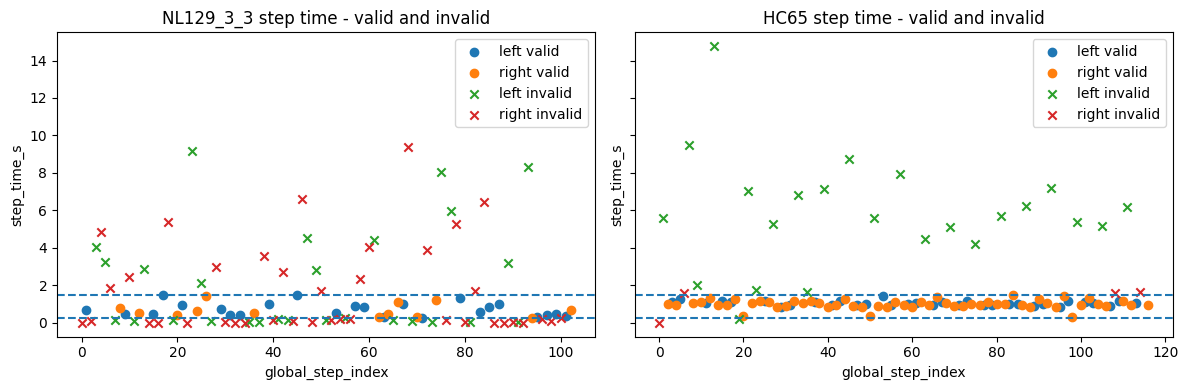

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

HC65_steps = HC65_steps.sort_values("global_step_index").copy()

valid_steps = HC65_steps[HC65_steps["valid"]]
invalid_steps = HC65_steps[~HC65_steps["valid"]]

for side, df_side in valid_steps.groupby("side"):
    axes[1].scatter(
        df_side["global_step_index"],
        df_side["step_time_s"],
        label=f"{side} valid"
    )

for side, df_side in invalid_steps.groupby("side"):
    axes[1].scatter(
        df_side["global_step_index"],
        df_side["step_time_s"],
        marker="x",
        label=f"{side} invalid"
    )

axes[1].axhline(0.25, linestyle="--")
axes[1].axhline(1.5, linestyle="--")

axes[1].set_title("HC65 step time - valid and invalid")
axes[1].set_xlabel("global_step_index")
axes[1].set_ylabel("step_time_s")
axes[1].legend()

NL129_steps = NL129_steps.sort_values("global_step_index").copy()

valid_steps = NL129_steps[NL129_steps["valid"]]
invalid_steps = NL129_steps[~NL129_steps["valid"]]

for side, df_side in valid_steps.groupby("side"):
    axes[0].scatter(
        df_side["global_step_index"],
        df_side["step_time_s"],
        label=f"{side} valid"
    )

for side, df_side in invalid_steps.groupby("side"):
    axes[0].scatter(
        df_side["global_step_index"],
        df_side["step_time_s"],
        marker="x",
        label=f"{side} invalid"
    )

axes[0].axhline(0.25, linestyle="--")
axes[0].axhline(1.5, linestyle="--")

axes[0].set_title("NL129_3_3 step time - valid and invalid")
axes[0].set_xlabel("global_step_index")
axes[0].set_ylabel("step_time_s")
axes[0].legend()


plt.tight_layout()
plt.show()

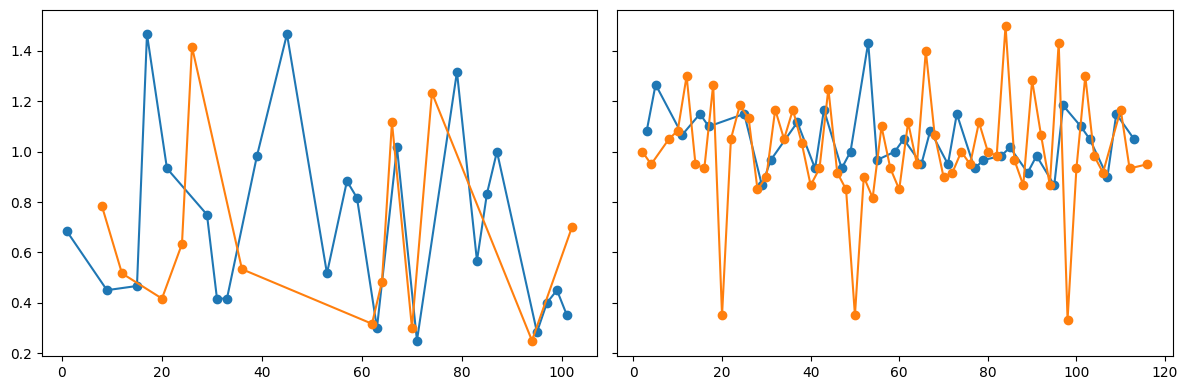

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

HC65_plot = HC65_steps[HC65_steps["valid"]].copy()

for side, df_side in HC65_plot.groupby("side"):
    df_side = df_side.sort_values("global_step_index")

    axes[1].plot(
        df_side["global_step_index"],
        df_side["step_time_s"],
        marker="o",
        linestyle="-",
        label=f"{side} step time",
    )

NL129_plot = NL129_steps[NL129_steps["valid"]].copy()

for side, df_side in NL129_plot.groupby("side"):
    df_side = df_side.sort_values("global_step_index")

    axes[0].plot(
        df_side["global_step_index"],
        df_side["step_time_s"],
        marker="o",
        linestyle="-",
        label=f"{side} step time",
    )

plt.tight_layout()
plt.show()

In [11]:
#HC65_steps = HC65_steps.sort_values("frame_index")
#HC65_valid = HC65_steps[HC65_steps["valid"]].copy()
#pd.set_option("display.max_rows", None)
#display(HC65_steps)

In [13]:
#print HC65_summary columns

print(HC65_summary.columns.tolist())

['video_id', 'run_hash_id', 'num_frames', 'fps', 'num_steps_right', 'num_steps_left', 'cadence_spm', 'gait_speed_px_per_s', 'mean_step_time_right_s', 'mean_step_time_left_s', 'mean_step_length_right_px', 'mean_step_length_left_px', 'std_step_time_right_s', 'std_step_time_left_s', 'std_step_length_right_px', 'std_step_length_left_px', 'schema_version']


In [ ]:
pd.set_option("display.max_rows", None)
display(HC65_summary)



,video_id,run_hash_id,num_frames,fps,num_steps_right,num_steps_left,cadence_spm,gait_speed_px_per_s,mean_step_time_right_s,mean_step_time_left_s,mean_step_length_right_px,mean_step_length_left_px,std_step_time_right_s,std_step_time_left_s,std_step_length_right_px,std_step_length_left_px,schema_version
0,HC65_3,20260526_220109,16495,60.0,70,62,NaN,49.810123,1.354048,3.013333,355.165375,408.754974,1.285658,3.062597,126.227394,132.577332,v1


In [15]:
display(NL129_summary)

,video_id,run_hash_id,num_frames,fps,num_steps_right,num_steps_left,cadence_spm,gait_speed_px_per_s,mean_step_time_right_s,mean_step_time_left_s,mean_step_length_right_px,mean_step_length_left_px,std_step_time_right_s,std_step_time_left_s,std_step_length_right_px,std_step_length_left_px,schema_version
0,NL129_3_3,20260526_221113,19597,60.0,103,64,NaN,31.312769,3.993527,1.708995,255.794098,692.729919,3.964482,2.452576,241.287811,489.661469,v1


In [7]:
# new schema format 

NL129_steps = pd.read_parquet("/home/projects/sipl-prj10496/project_files/outputs/hrnet_wholebody_output/20260529_165548/NL129_3_3_steps.parquet")
NL129_summary = pd.read_parquet("/home/projects/sipl-prj10496/project_files/outputs/hrnet_wholebody_output/20260529_165548/NL129_3_3_summary.parquet")
HC65_steps_2905 = pd.read_parquet("/home/projects/sipl-prj10496/project_files/outputs/hrnet_wholebody_output/20260529_162809/HC65_3_steps.parquet")
HC65_summary_2905 = pd.read_parquet("/home/projects/sipl-prj10496/project_files/outputs/hrnet_wholebody_output/20260529_162809/HC65_3_summary.parquet")

In [21]:
#display(HC65_summary_2905)


In [22]:
#display(HC65_steps_2905)


Spread the data using PCA + UMAP

In [8]:
# load parquet data
steps_paths = glob.glob("/home/projects/sipl-prj10496/project_files/outputs/hrnet_wholebody_output/*/*_steps.parquet")
steps_df = pd.concat([pd.read_parquet(path) for path in steps_paths], ignore_index=True)

# keep valid steps only
steps_df = steps_df[steps_df["valid"]].copy()

steps_df["group"] = np.where(steps_df["video_id"].str.startswith("NL"), "NL", "HC")

#print(steps_df.columns.tolist())
# select features
feature_cols = ["step_time_s", "swing_time_s", "stance_time_s"]
steps_df = steps_df.dropna(subset=feature_cols).copy()

X = steps_df[feature_cols].astype(float).values


In [9]:
# standardize features and calculate PCA + UMAP
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import umap.umap_ as umap

Xz = StandardScaler().fit_transform(X)

pca = PCA(n_components=2, random_state=0)

X_pca = pca.fit_transform(Xz)

um = umap.UMAP(n_neighbors=20, min_dist=0.1, random_state=0)
X_umap = um.fit_transform(Xz)

/home/projects/sipl-prj10496/anaconda3/envs/mmpose_env/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


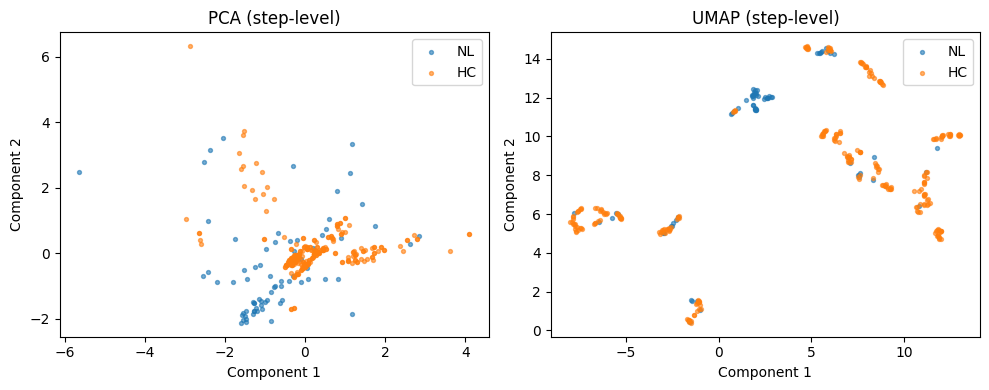

In [10]:
colors = {"NL": "#1f77b4", "HC": "#ff7f0e"}

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for g in ["NL", "HC"]:
    mask = steps_df["group"] == g
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], s=8, alpha=0.6, label=g, c=colors[g])
    axes[1].scatter(X_umap[mask, 0], X_umap[mask, 1], s=8, alpha=0.6, label=g, c=colors[g])

axes[0].set_title("PCA (step-level)")
axes[1].set_title("UMAP (step-level)")
for ax in axes:
    ax.legend()
    ax.set_xlabel("Component 1")
    ax.set_ylabel("Component 2")
plt.tight_layout()
plt.show()

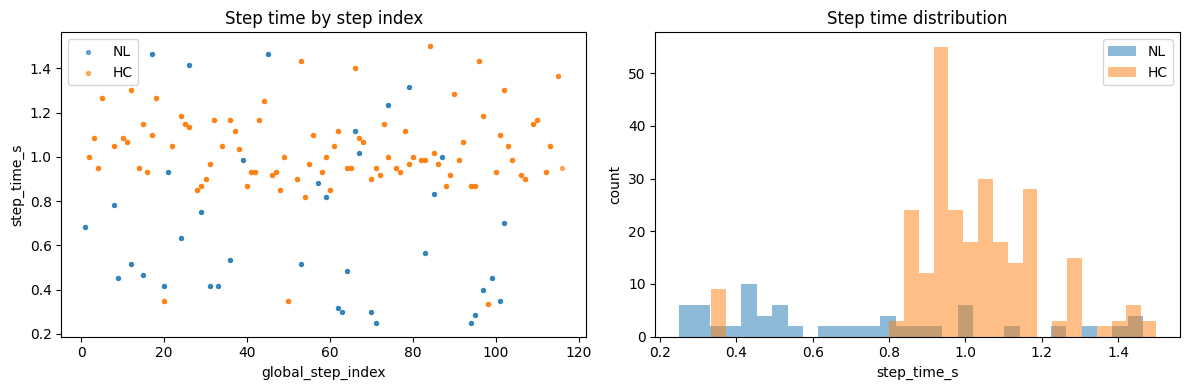

In [12]:
# assumes steps_df already exists
steps_df = steps_df.sort_values("global_step_index")
colors = {"NL": "#1f77b4", "HC": "#ff7f0e"}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Scatter (step_time vs index)
for g in ["NL", "HC"]:
    mask = steps_df["group"] == g
    axes[0].scatter(
        steps_df.loc[mask, "global_step_index"],
        steps_df.loc[mask, "step_time_s"],
        s=8, alpha=0.6, label=g, c=colors[g]
    )
axes[0].set_xlabel("global_step_index")
axes[0].set_ylabel("step_time_s")
axes[0].set_title("Step time by step index")
axes[0].legend()

# Histogram
for g in ["NL", "HC"]:
    mask = steps_df["group"] == g
    axes[1].hist(
        steps_df.loc[mask, "step_time_s"],
        bins=30, alpha=0.5, label=g, color=colors[g]
    )
axes[1].set_xlabel("step_time_s")
axes[1].set_ylabel("count")
axes[1].set_title("Step time distribution")
axes[1].legend()

plt.tight_layout()
plt.show()

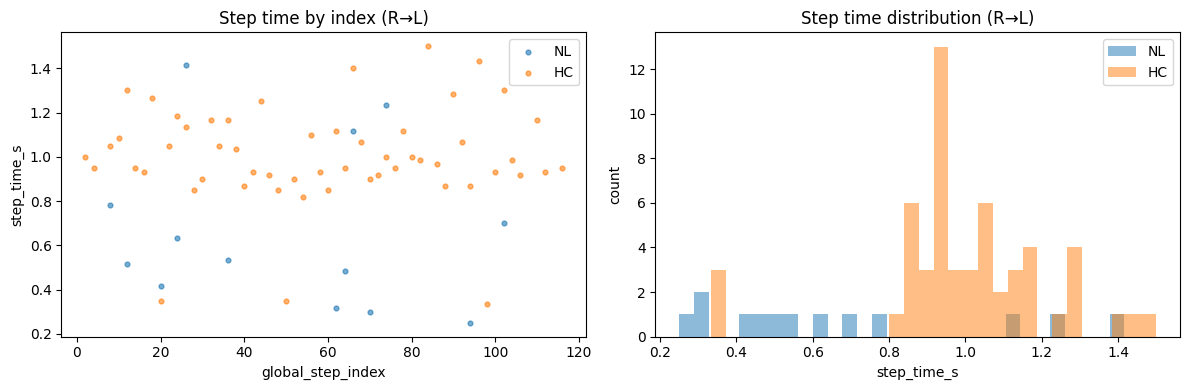

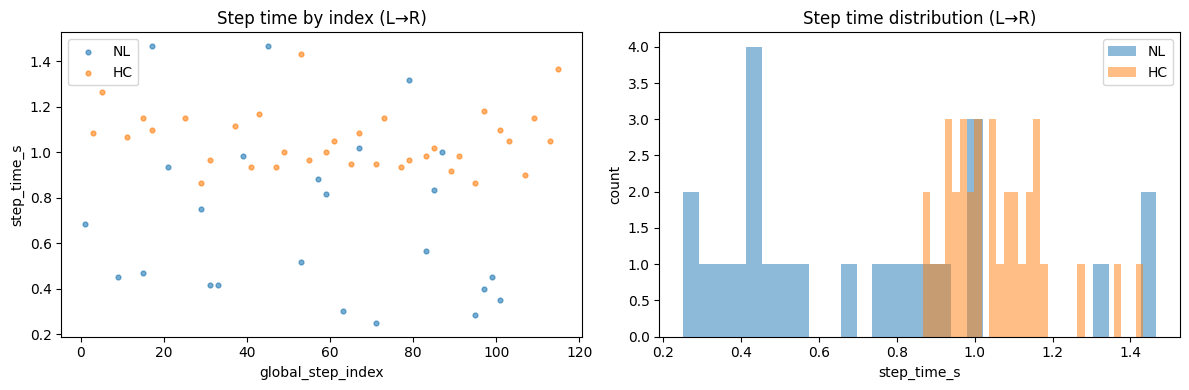

In [19]:
# use the two specific step dfs
nl_steps = NL129_steps.copy()
hc_steps = HC65_steps_2905.copy()

# keep valid only (optional)
nl_steps = nl_steps[nl_steps["valid"]].copy()
hc_steps = hc_steps[hc_steps["valid"]].copy()

colors = {"NL": "#1f77b4", "HC": "#ff7f0e"}

for direction, side in [("R→L", "left"), ("L→R", "right")]:
    nl_side = nl_steps[nl_steps["side"] == side]
    hc_side = hc_steps[hc_steps["side"] == side]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Scatter: step_time by index
    axes[0].scatter(
        nl_side["global_step_index"], nl_side["step_time_s"],
        s=12, alpha=0.6, label="NL", c=colors["NL"]
    )
    axes[0].scatter(
        hc_side["global_step_index"], hc_side["step_time_s"],
        s=12, alpha=0.6, label="HC", c=colors["HC"]
    )
    axes[0].set_xlabel("global_step_index")
    axes[0].set_ylabel("step_time_s")
    axes[0].set_title(f"Step time by index ({direction})")
    axes[0].legend()

    # Histogram
    axes[1].hist(
        nl_side["step_time_s"], bins=30, alpha=0.5, label="NL", color=colors["NL"]
    )
    axes[1].hist(
        hc_side["step_time_s"], bins=30, alpha=0.5, label="HC", color=colors["HC"]
    )
    axes[1].set_xlabel("step_time_s")
    axes[1].set_ylabel("count")
    axes[1].set_title(f"Step time distribution ({direction})")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

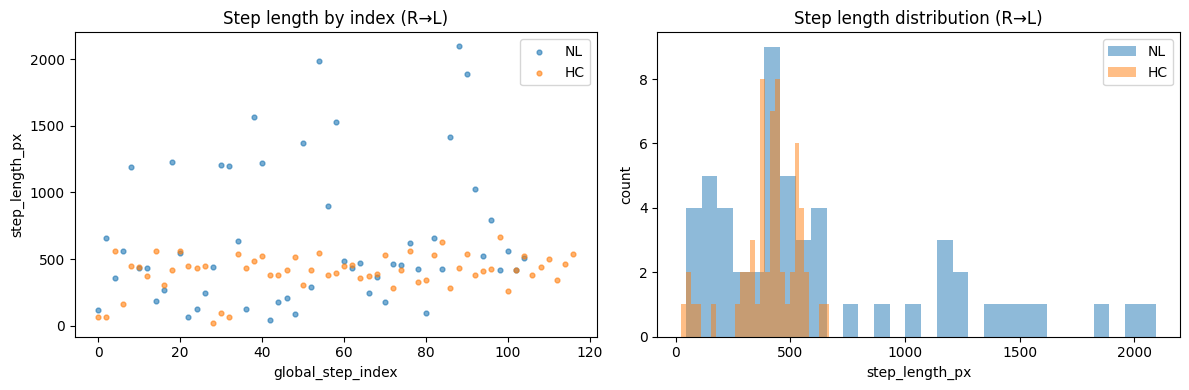

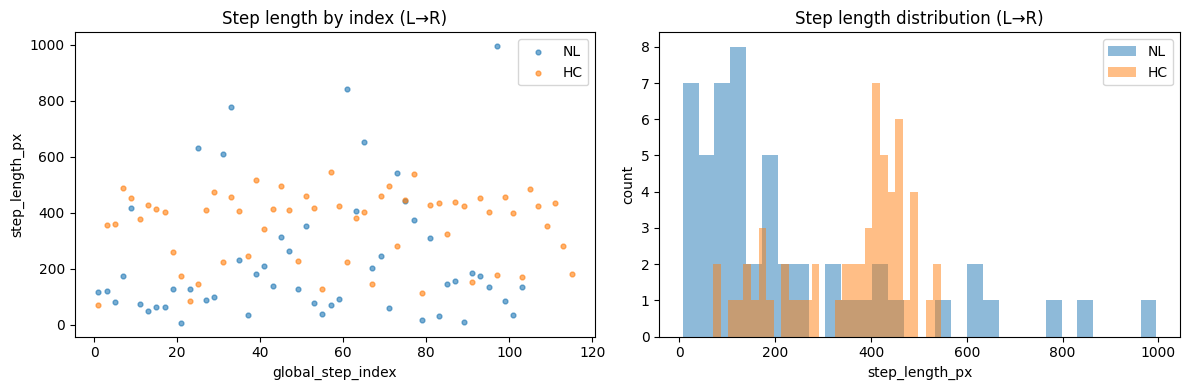

In [22]:
# assumes NL129_spatial and HC65_spatial are loaded
nl_spatial = NL129_spatial.copy()
hc_spatial = HC65_spatial.copy()

colors = {"NL": "#1f77b4", "HC": "#ff7f0e"}

for direction, side in [("R→L", "left"), ("L→R", "right")]:
    nl_side = nl_spatial[nl_spatial["side"] == side]
    hc_side = hc_spatial[hc_spatial["side"] == side]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Scatter: step_length by index
    axes[0].scatter(
        nl_side["global_step_index"], nl_side["step_length_px"],
        s=12, alpha=0.6, label="NL", c=colors["NL"]
    )
    axes[0].scatter(
        hc_side["global_step_index"], hc_side["step_length_px"],
        s=12, alpha=0.6, label="HC", c=colors["HC"]
    )
    axes[0].set_xlabel("global_step_index")
    axes[0].set_ylabel("step_length_px")
    axes[0].set_title(f"Step length by index ({direction})")
    axes[0].legend()

    # Histogram
    axes[1].hist(
        nl_side["step_length_px"], bins=30, alpha=0.5, label="NL", color=colors["NL"]
    )
    axes[1].hist(
        hc_side["step_length_px"], bins=30, alpha=0.5, label="HC", color=colors["HC"]
    )
    axes[1].set_xlabel("step_length_px")
    axes[1].set_ylabel("count")
    axes[1].set_title(f"Step length distribution ({direction})")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

In [23]:
def iqr_bounds(x, k=1.5):
    q1 = x.quantile(0.25)
    q3 = x.quantile(0.75)
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

def mad_bounds(x, k=3.5):
    med = x.median()
    mad = (x - med).abs().median()
    sigma = 1.4826 * mad
    return med - k * sigma, med + k * sigma

In [34]:
HC65_spatial_bounds = {}
NL129_spatial_bounds = {}
for side, df_side in HC65_spatial.groupby("side"):
    lo, hi = iqr_bounds(df_side["step_length_px"])
    lo = max(lo, 0)  # step length can't be negative
    HC65_spatial_bounds[side] = (lo, hi)
for side, df_side in NL129_spatial.groupby("side"):
    lo, hi = iqr_bounds(df_side["step_length_px"])
    lo = max(lo, 0)  # step length can't be negative
    NL129_spatial_bounds[side] = (lo, hi)

print("HC65 spatial bounds:")
print(HC65_spatial_bounds)
print("NL129 spatial bounds:")
print(NL129_spatial_bounds)

HC65 spatial bounds:
{'left': (153.91403198242188, 723.7502136230469), 'right': (0, 737.6261596679688)}
NL129 spatial bounds:
{'left': (0, 1844.2635498046875), 'right': (0, 658.527587890625)}


In [35]:
def mark_outliers(df, bounds):
    out = df.copy()
    lo = out["side"].map(lambda s: bounds[s][0])
    hi = out["side"].map(lambda s: bounds[s][1])
    out["length_outlier"] = (out["step_length_px"] < lo) | (out["step_length_px"] > hi)
    return out

In [38]:
HC65_spatial_out = mark_outliers(HC65_spatial, HC65_spatial_bounds)
NL129_spatial_out = mark_outliers(NL129_spatial, NL129_spatial_bounds)

#print the maximal step length value
print("Max step length (HC65):", HC65_spatial["step_length_px"].max())
print("Max step length (NL129):", NL129_spatial["step_length_px"].max())


Max step length (HC65): 668.808349609375
Max step length (NL129): 2096.548583984375


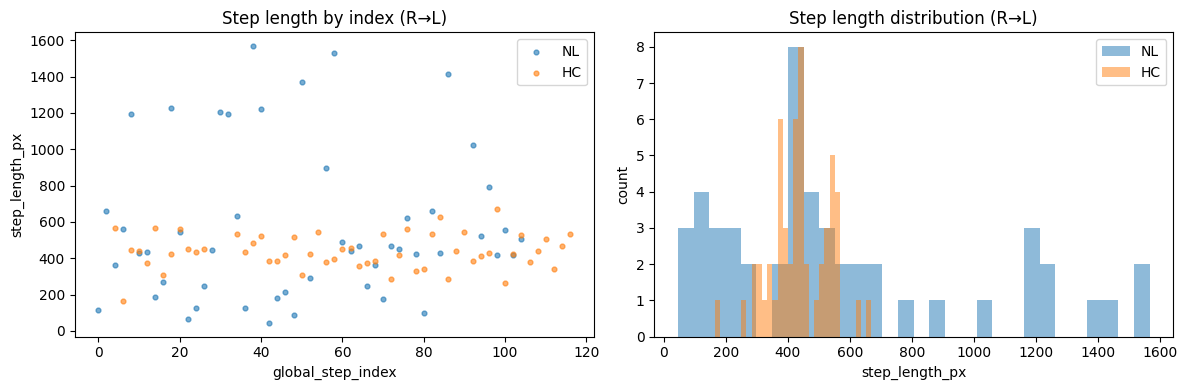

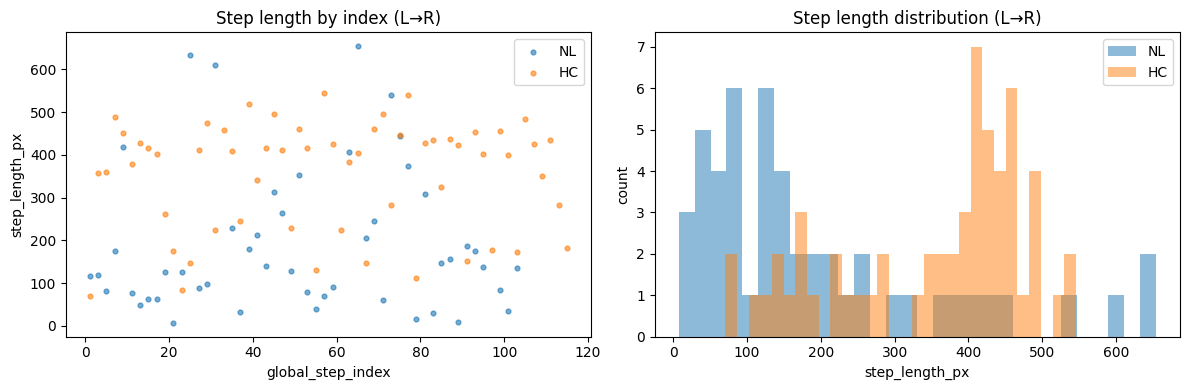

In [39]:
# assumes NL129_spatial_out / HC65_spatial_out already have length_outlier
nl_spatial = NL129_spatial_out[~NL129_spatial_out["length_outlier"]].copy()
hc_spatial = HC65_spatial_out[~HC65_spatial_out["length_outlier"]].copy()

colors = {"NL": "#1f77b4", "HC": "#ff7f0e"}

for direction, side in [("R→L", "left"), ("L→R", "right")]:
    nl_side = nl_spatial[nl_spatial["side"] == side]
    hc_side = hc_spatial[hc_spatial["side"] == side]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].scatter(
        nl_side["global_step_index"], nl_side["step_length_px"],
        s=12, alpha=0.6, label="NL", c=colors["NL"]
    )
    axes[0].scatter(
        hc_side["global_step_index"], hc_side["step_length_px"],
        s=12, alpha=0.6, label="HC", c=colors["HC"]
    )
    axes[0].set_xlabel("global_step_index")
    axes[0].set_ylabel("step_length_px")
    axes[0].set_title(f"Step length by index ({direction})")
    axes[0].legend()

    axes[1].hist(
        nl_side["step_length_px"], bins=30, alpha=0.5, label="NL", color=colors["NL"]
    )
    axes[1].hist(
        hc_side["step_length_px"], bins=30, alpha=0.5, label="HC", color=colors["HC"]
    )
    axes[1].set_xlabel("step_length_px")
    axes[1].set_ylabel("count")
    axes[1].set_title(f"Step length distribution ({direction})")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

In [33]:
(NL129_spatial["step_length_px"] < 0).any(), (HC65_spatial["step_length_px"] < 0).any()

(False, False)

In [67]:
# load parquet data

cutoff = "20260529_173236"
paths = glob.glob("/home/projects/sipl-prj10496/project_files/outputs/hrnet_wholebody_output/*/*_steps.parquet")

filtered = [
    p for p in paths
    if os.path.basename(os.path.dirname(p)) >= cutoff
]


steps_df = pd.concat([pd.read_parquet(path) for path in filtered], ignore_index=True)

# keep valid steps only
steps_df = steps_df[steps_df["valid"]].copy()

steps_df["group"] = np.where(steps_df["video_id"].str.startswith("NL"), "NL", "HC")

#print(steps_df.columns.tolist())
# select features
feature_cols = ["step_time_s", "swing_time_s", "stance_time_s"]
steps_df = steps_df.dropna(subset=feature_cols).copy()

X = steps_df[feature_cols].astype(float).values


In [105]:
display(steps_df)
steps_df['video_id'].unique()

,video_id,run_hash_id,global_step_index,side,hs_frame,prev_opposite_hs_frame,to_frame,next_same_side_hs_frame,step_time_s,stance_time_s,swing_time_s,valid,group
1,NL129_3_3,20260529_173236,1,right,553,553,584,599,0.683333,0.516667,0.250000,True,NL
8,NL129_3_3,20260529_173236,8,left,1841,1616,1865,1915,0.783333,0.400000,0.833333,True,NL
9,NL129_3_3,20260529_173236,9,right,1888,1841,1919,2091,0.450000,0.516667,2.866667,True,NL
12,NL129_3_3,20260529_173236,12,left,2223,2191,2383,2427,0.516667,2.666667,0.733333,True,NL
15,NL129_3_3,20260529_173236,15,right,2427,2427,2598,2455,0.466667,2.850000,-2.383333,True,NL
...,...,...,...,...,...,...,...,...,...,...,...,...,...
442,NL124_3_3,20260529_181925,102,left,22136,21599,22264,22489,1.450000,2.133333,3.750000,True,NL
444,NL124_3_3,20260529_181925,104,left,22489,22223,22534,22603,1.150000,0.750000,1.150000,True,NL
445,NL124_3_3,20260529_181925,105,right,22558,22489,22601,22715,0.750000,0.716667,1.900000,True,NL
450,NL124_3_3,20260529_181925,110,left,23535,23294,23573,23678,1.100000,0.633333,1.750000,True,NL


array(['NL129_3_3', 'HC65_3', 'HC66_3', 'NL124_3_3'], dtype=object)

In [73]:

cutoff = "20260529_173236"
paths = glob.glob("/home/projects/sipl-prj10496/project_files/outputs/hrnet_wholebody_output/*/*_summary.parquet")

filtered = [
    p for p in paths
    if os.path.basename(os.path.dirname(p)) >= cutoff
]

summary_df = pd.concat([pd.read_parquet(path) for path in filtered], ignore_index=True)

display(summary_df)

,video_id,run_hash_id,num_frames,fps,num_steps_right,num_steps_left,cadence_spm,gait_speed_px_per_s,mean_step_time_right_s,mean_step_time_left_s,mean_step_length_right_px,mean_step_length_left_px,std_step_time_right_s,std_step_time_left_s,std_step_length_right_px,std_step_length_left_px,schema_version
0,NL129_3_3,20260529_173236,19597,60.0,52,53,NaN,NaN,1.489744,1.460692,255.794098,692.729919,2.195759,2.098110,241.287811,489.661469,v1
1,HC65_3,20260529_173308,16495,60.0,58,59,NaN,NaN,2.939368,1.015537,355.165375,408.754974,2.976325,0.286134,126.227394,132.577332,v1
2,HC66_3,20260529_181834,13963,60.0,59,59,NaN,NaN,2.324859,0.759322,356.072357,436.685425,2.667569,0.252991,163.120880,147.583679,v1
3,NL124_3_3,20260529_181925,24227,60.0,56,57,NaN,NaN,4.362500,1.620760,348.049744,272.284576,4.424313,0.903660,99.280754,143.929092,v1


In [110]:
# standardize features and calculate PCA + UMAP
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import umap.umap_ as umap

Xz = StandardScaler().fit_transform(X)

pca = PCA(n_components=2, random_state=0)

X_pca = pca.fit_transform(Xz)

um = umap.UMAP(n_neighbors=40, min_dist=0.1, random_state=0)
X_umap = um.fit_transform(Xz)

/home/projects/sipl-prj10496/anaconda3/envs/mmpose_env/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


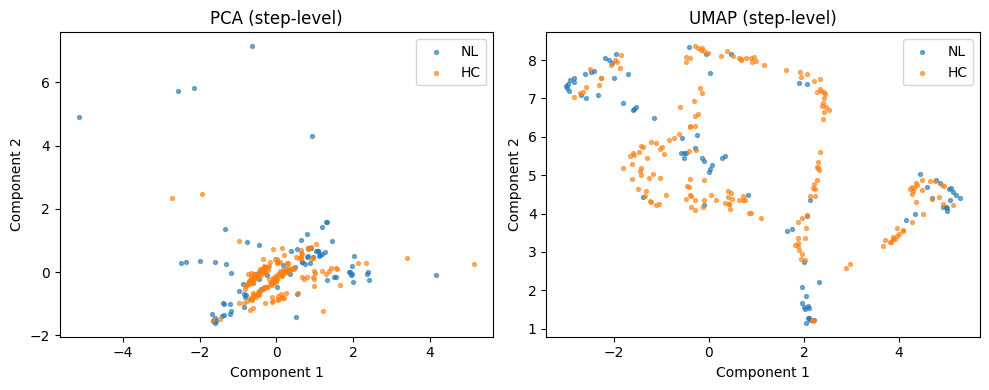

In [111]:
colors = {"NL": "#1f77b4", "HC": "#ff7f0e"}

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for g in ["NL", "HC"]:
    mask = steps_df["group"] == g
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], s=8, alpha=0.6, label=g, c=colors[g])
    axes[1].scatter(X_umap[mask, 0], X_umap[mask, 1], s=8, alpha=0.6, label=g, c=colors[g])

axes[0].set_title("PCA (step-level)")
axes[1].set_title("UMAP (step-level)")
for ax in axes:
    ax.legend()
    ax.set_xlabel("Component 1")
    ax.set_ylabel("Component 2")
plt.tight_layout()
plt.show()

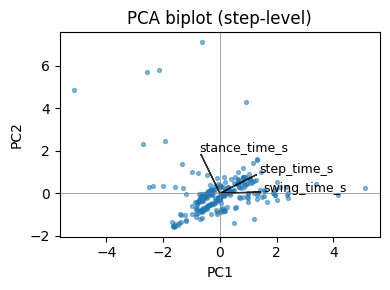

In [112]:
# biplot: points + feature arrows
plt.figure(figsize=(4, 3))

# scatter of PCA scores
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=8, alpha=0.5)

# feature arrows (loadings)
loadings = pca.components_.T
for i, feat in enumerate(feature_cols):
    plt.arrow(0, 0, loadings[i, 0]*2, loadings[i, 1]*2,
              color="black", alpha=0.8, head_width=0.03)
    plt.text(loadings[i, 0]*2.2, loadings[i, 1]*2.2, feat, fontsize=9)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA biplot (step-level)")
plt.axhline(0, color="gray", linewidth=0.5)
plt.axvline(0, color="gray", linewidth=0.5)
plt.tight_layout()
plt.show()

In [113]:
# after fitting PCA
loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_cols,
    columns=["PC1", "PC2"]
)
print(loadings)

print("Explained variance:", pca.explained_variance_ratio_)

                    PC1       PC2
step_time_s    0.634551  0.432073
swing_time_s   0.700358  0.029210
stance_time_s -0.326871  0.901365
Explained variance: [0.38612753 0.3314468 ]


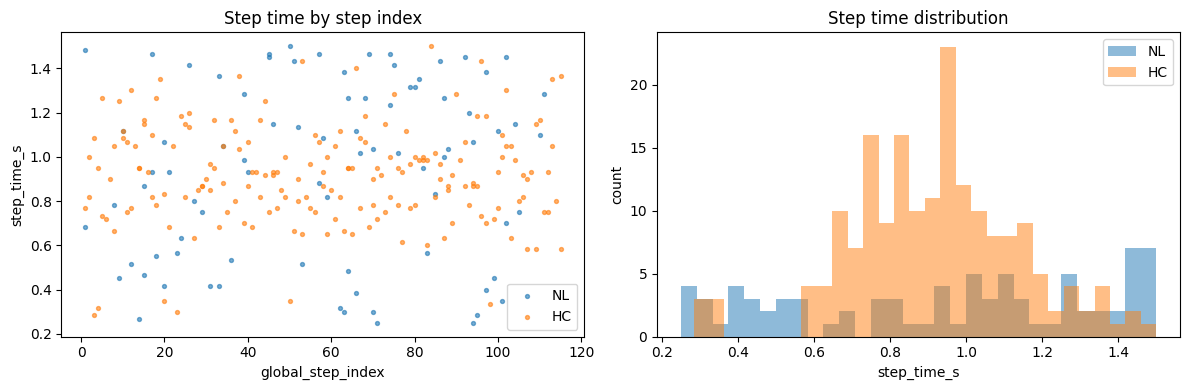

In [114]:
# assumes steps_df already exists
steps_df = steps_df.sort_values("global_step_index")
colors = {"NL": "#1f77b4", "HC": "#ff7f0e"}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Scatter (step_time vs index)
for g in ["NL", "HC"]:
    mask = steps_df["group"] == g
    axes[0].scatter(
        steps_df.loc[mask, "global_step_index"],
        steps_df.loc[mask, "step_time_s"],
        s=8, alpha=0.6, label=g, c=colors[g]
    )
axes[0].set_xlabel("global_step_index")
axes[0].set_ylabel("step_time_s")
axes[0].set_title("Step time by step index")
axes[0].legend()

# Histogram
for g in ["NL", "HC"]:
    mask = steps_df["group"] == g
    axes[1].hist(
        steps_df.loc[mask, "step_time_s"],
        bins=30, alpha=0.5, label=g, color=colors[g]
    )
axes[1].set_xlabel("step_time_s")
axes[1].set_ylabel("count")
axes[1].set_title("Step time distribution")
axes[1].legend()

plt.tight_layout()
plt.show()

In [118]:

cutoff = "20260529_173236"
spatial_paths = glob.glob("/home/projects/sipl-prj10496/project_files/outputs/hrnet_wholebody_output/*/*_spatial.parquet")

filtered = [
    p for p in spatial_paths
    if os.path.basename(os.path.dirname(p)) >= cutoff
]

spatial_df = pd.concat([pd.read_parquet(path) for path in filtered], ignore_index=True)

#display(spatial_df)

In [120]:
# spatial_df has step_length_px; steps_df has step_time_s


merged = spatial_df.merge(
    steps_df[["video_id", "side", "global_step_index", "step_time_s"]],
    on=["video_id", "side", "global_step_index"],
    how="inner"
)

feature_cols = ["step_length_px", "step_time_s"]
merged = merged.dropna(subset=feature_cols).copy()


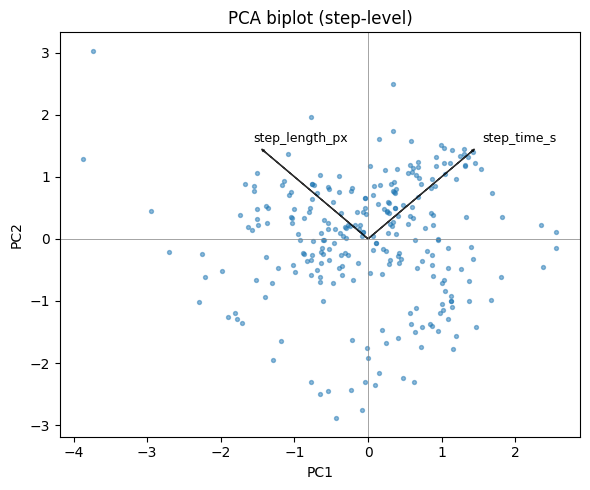

In [121]:
# biplot: points + feature arrows
plt.figure(figsize=(6, 5))

# scatter of PCA scores
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=8, alpha=0.5)

# feature arrows (loadings)
loadings = pca.components_.T
for i, feat in enumerate(feature_cols):
    plt.arrow(0, 0, loadings[i, 0]*2, loadings[i, 1]*2,
              color="black", alpha=0.8, head_width=0.03)
    plt.text(loadings[i, 0]*2.2, loadings[i, 1]*2.2, feat, fontsize=9)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA biplot (step-level)")
plt.axhline(0, color="gray", linewidth=0.5)
plt.axvline(0, color="gray", linewidth=0.5)
plt.tight_layout()
plt.show()

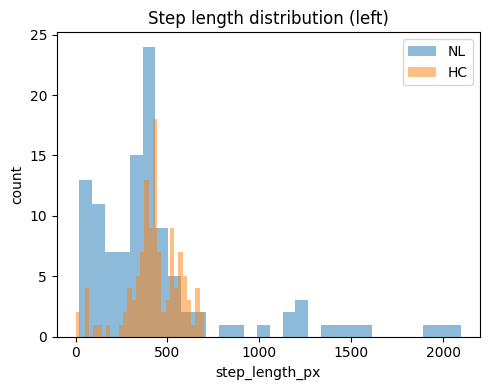

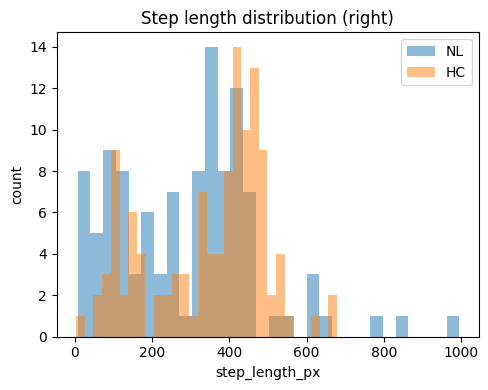

In [122]:
# load all spatial parquet files
spatial_paths = glob.glob("/home/projects/sipl-prj10496/project_files/outputs/hrnet_wholebody_output/*/*_spatial.parquet")
spatial_df = pd.concat([pd.read_parquet(p) for p in spatial_paths], ignore_index=True)

# label group from video_id
spatial_df["group"] = np.where(spatial_df["video_id"].str.startswith("NL"), "NL", "HC")

# keep valid rows if you have a flag; otherwise skip this
# spatial_df = spatial_df[spatial_df["valid"]].copy()

# drop NaNs on the spatial metric
spatial_df = spatial_df.dropna(subset=["step_length_px"]).copy()

colors = {"NL": "#1f77b4", "HC": "#ff7f0e"}

for side in ["left", "right"]:
    df_side = spatial_df[spatial_df["side"] == side]
    plt.figure(figsize=(5, 4))
    for g in ["NL", "HC"]:
        plt.hist(
            df_side.loc[df_side["group"] == g, "step_length_px"],
            bins=30,
            alpha=0.5,
            label=g,
            color=colors[g],
        )
    plt.title(f"Step length distribution ({side})")
    plt.xlabel("step_length_px")
    plt.ylabel("count")
    plt.legend()
    plt.tight_layout()
    plt.show()